# 09 — Final synthesis: what predicts CT-level voter turnout in Toronto

This notebook is the last step in a nine-notebook pipeline that builds a census-tract (CT) level
model of Toronto voter turnout from neighbourhood demographic, socioeconomic, housing, and
built-form characteristics. It does **no new modelling** — no refitting, no re-running PLS, no new
analysis. It reads the already-computed outputs of notebooks 04–08 and pulls them together into a
single, honest synthesis.

**Structure (9 sections, matching the required synthesis outline):**
1. The final turnout definition and denominator
2. The final predictor pool: what's in, what was removed, and why
3. The selected PLS specification and its predictive performance
4. The main latent components and their interpretation
5. Which components are most strongly related to turnout
6. Whether the same broad findings appear across election levels
7. What the robustness checks support (and what they don't)
8. What remains ambiguous or should not be over-interpreted
9. The strongest public-facing candidates


In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 140)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"


In [2]:
# --- Paths — every file this notebook reads, all already produced by notebooks 04-08 ---
REPO_ROOT = Path.cwd().resolve().parents[1]
NB_DIR = REPO_ROOT / "analysis/toronto_election_turnout"
OUT_ROOT = REPO_ROOT / "data/toronto_election_turnout"  # relocated output root (NB_DIR above is kept for notebook-file paths only)
FEATURES_DIR = OUT_ROOT / "features"
MODEL_DIR = OUT_ROOT / "model"

PREDICTOR_METADATA_PATH = FEATURES_DIR / "predictor_metadata.csv"
MODEL_INPUT_CSV_PATH = FEATURES_DIR / "ct_model_input.csv"

PLS_SUMMARY_PATH = MODEL_DIR / "pls_summary.csv"
PLS_COMPONENT_CV_PATH = MODEL_DIR / "pls_component_cv.csv"
PLS_LOADINGS_PATH = MODEL_DIR / "pls_component_loadings.csv"
PLS_COMPOSITION_PATH = MODEL_DIR / "pls_component_composition.csv"
PLS_VIP_PATH = MODEL_DIR / "pls_variable_importance.csv"
PLS_REFERENCE_GEOGRAPHIES_PATH = MODEL_DIR / "pls_reference_geographies.csv"

ROBUSTNESS_SPATIAL_CV_PATH = MODEL_DIR / "robustness_spatial_cv_summary.csv"
ROBUSTNESS_CROSS_OUTCOME_PATH = MODEL_DIR / "robustness_cross_outcome_loadings.csv"
ROBUSTNESS_BOOTSTRAP_STABILITY_PATH = MODEL_DIR / "robustness_bootstrap_stability_summary.csv"
ROBUSTNESS_BOOTSTRAP_SPARSE_FREQ_PATH = MODEL_DIR / "robustness_bootstrap_sparse_pls_selection_frequency.csv"
ROBUSTNESS_SPARSE_SELECTION_PATH = MODEL_DIR / "robustness_sparse_pls_selection.csv"
ROBUSTNESS_MODEL_COMPARISON_PATH = MODEL_DIR / "robustness_model_comparison_summary.csv"

NB04_PATH = NB_DIR / "04_interpolate_votes_to_tracts.ipynb"
NB07_PATH = NB_DIR / "07_fit_latent_pls_model.ipynb"
NB08_PATH = NB_DIR / "08_robustness_and_alternative_models.ipynb"

for p in [PREDICTOR_METADATA_PATH, MODEL_INPUT_CSV_PATH, PLS_SUMMARY_PATH, PLS_COMPONENT_CV_PATH,
          PLS_LOADINGS_PATH, PLS_COMPOSITION_PATH, PLS_VIP_PATH, PLS_REFERENCE_GEOGRAPHIES_PATH,
          ROBUSTNESS_SPATIAL_CV_PATH, ROBUSTNESS_CROSS_OUTCOME_PATH,
          ROBUSTNESS_BOOTSTRAP_STABILITY_PATH, ROBUSTNESS_BOOTSTRAP_SPARSE_FREQ_PATH,
          ROBUSTNESS_SPARSE_SELECTION_PATH, ROBUSTNESS_MODEL_COMPARISON_PATH,
          NB04_PATH, NB07_PATH, NB08_PATH]:
    assert p.exists(), f"missing: {p}"
print("All source files found.")

All source files found.


In [3]:
def notebook_output_texts(nb_path: Path, needle: str) -> list[str]:
    '''Pull the printed stdout of every code-cell output in `nb_path` that contains `needle`.

    Used below to ground a handful of numbers (an sklearn cross-check, an internal-consistency
    refit, a boundary-geometry verification) that notebooks 04/07/08 printed but did not persist
    to a CSV -- rather than retype those numbers from memory, we read them directly out of the
    saved notebook output.
    '''
    nb = json.loads(nb_path.read_text())
    texts = []
    for cell in nb["cells"]:
        if cell.get("cell_type") != "code":
            continue
        for out in cell.get("outputs", []):
            if "text" in out:
                t = "".join(out["text"])
                if needle in t:
                    texts.append(t)
    return texts

## 1. The final turnout definition and denominator

The modelled outcome, `mean_turnout`, is the **average of three election-level turnout rates**:
the 2023 municipal mayoral race, the 2025 provincial election, and the 2025 federal election. Each
of those three rates is defined as

$$\text{turnout}_\text{election} = \frac{\text{votes cast}}{\text{citizen\_canadian\_18over}}$$

i.e. **votes cast divided by the number of Canadian citizens aged 18+ in the CT** — not registered
electors. This denominator was chosen because the registered-elector count on record for a CT is
itself a product of list maintenance and advance/mail-in administrative quirks (and, for the
municipal race, ward-boundary apportionment), whereas the citizen-eligible population is a stable
demographic denominator that supports comparison across three different electoral systems and
geographies.

In [4]:
model_input = pd.read_csv(MODEL_INPUT_CSV_PATH)

turnout_cols = ["mean_turnout", "municipal_turnout", "provincial_turnout", "federal_turnout"]
diagnostic_cols = [f"{lvl}_turnout_electors_diagnostic" for lvl in ("municipal", "provincial", "federal")]

print(f"ct_model_input.csv: {model_input.shape[0]} CTs, {model_input.shape[1]} columns\n")

# Verify the stated definition: mean_turnout == average of the three per-election turnout columns
avg_of_three = model_input[["municipal_turnout", "provincial_turnout", "federal_turnout"]].mean(axis=1)
diff = (avg_of_three - model_input["mean_turnout"]).abs()
imputed_any = model_input[[c for c in model_input.columns if c.endswith("_turnout_median_imputed")]].any(axis=1)
print(f"max |avg(municipal, provincial, federal) - mean_turnout| = {diff.max():.6f}")
print(f"  rows where this identity does not hold exactly: {(diff > 1e-9).sum()} of {len(model_input)}")
print(f"  of those, rows touched by median imputation on a turnout column: {(diff > 1e-9).values[imputed_any.values].sum()}")
print("  (the only rows that deviate are the handful imputed independently per-column; every ")
print("   non-imputed CT satisfies the definition exactly)\n")

print("Descriptive stats, per-election and mean turnout (citizen-denominator, the modelled outcome):")
display(model_input[turnout_cols].describe().T[["mean", "std", "min", "max"]].round(3))

ct_model_input.csv: 585 CTs, 204 columns

max |avg(municipal, provincial, federal) - mean_turnout| = 0.006847
  rows where this identity does not hold exactly: 2 of 585
  of those, rows touched by median imputation on a turnout column: 2
  (the only rows that deviate are the handful imputed independently per-column; every 
   non-imputed CT satisfies the definition exactly)

Descriptive stats, per-election and mean turnout (citizen-denominator, the modelled outcome):


,mean,std,min,max
mean_turnout,0.523,0.087,0.304,0.979
municipal_turnout,0.389,0.104,0.102,0.827
provincial_turnout,0.475,0.092,0.221,0.973
federal_turnout,0.704,0.099,0.477,1.212


In [5]:
print("Registered-elector-based diagnostic columns (secondary cross-check only, never the model's")
print("target) and their correlation with the citizen-denominator turnout actually modelled:\n")
for lvl, diag in zip(("municipal", "provincial", "federal"), diagnostic_cols):
    corr = model_input[f"{lvl}_turnout"].corr(model_input[diag])
    print(f"  {lvl + '_turnout':22s} vs {diag:42s} r = {corr:.3f}")

Registered-elector-based diagnostic columns (secondary cross-check only, never the model's
target) and their correlation with the citizen-denominator turnout actually modelled:

  municipal_turnout      vs municipal_turnout_electors_diagnostic      r = 0.704
  provincial_turnout     vs provincial_turnout_electors_diagnostic     r = 0.680
  federal_turnout        vs federal_turnout_electors_diagnostic        r = 0.641


**Takeaway.** `mean_turnout` is, to within floating-point/imputation noise, exactly the simple
average of `municipal_turnout`, `provincial_turnout`, and `federal_turnout` — all three
citizen-denominator rates are carried alongside it in `ct_model_input.csv` and used directly in
Section 6's per-election refits. The registered-elector-based `*_turnout_electors_diagnostic`
columns are also present in the table, but only as a sanity-check comparison (correlated at
r ≈ 0.64–0.70 with the citizen-denominator rate they shadow) — they are never the regression
target anywhere in this pipeline.

## 2. The final predictor pool

This round's predictor pool is a **fixed, pre-approved list of exactly 70 variables across 14
named families** — decided upstream of notebook 06 and treated as ground truth, not an open-ended
screen. `predictor_metadata.csv` is the authoritative record of what is in the pool, what was
considered and left out, and why.

In [6]:
predictor_metadata = pd.read_csv(PREDICTOR_METADATA_PATH)
admitted = predictor_metadata[predictor_metadata["family"] != "excluded"].copy()
excluded = predictor_metadata[predictor_metadata["family"] == "excluded"].copy()

print(f"Total rows in predictor_metadata.csv: {len(predictor_metadata)}")
print(f"Admitted predictors (fed into the PLS model): {len(admitted)}")
print(f"Documented-but-excluded candidate columns: {len(excluded)}")
print(f"Families represented among admitted predictors: {admitted['family'].nunique()}\n")

family_counts = admitted["family"].value_counts().sort_index().rename("n_variables").to_frame()
family_counts.loc["TOTAL"] = family_counts["n_variables"].sum()
family_counts

Total rows in predictor_metadata.csv: 100
Admitted predictors (fed into the PLS model): 70
Documented-but-excluded candidate columns: 30
Families represented among admitted predictors: 14



,n_variables
family,
accessibility,9
age_life_stage,4
culture_language,4
education,3
household_family,6
housing_affordability_need,4
housing_form,6
housing_tenure_stability,3
immigration_citizenship,5


In [7]:
# Confirm no retired variable family survives anywhere in the active model-input table
import re as _re
forbidden_pattern = _re.compile(r"block4|ksi|311|development_appl|ethnic_divers|diversity_index", _re.I)
forbidden_hits = [c for c in model_input.columns if forbidden_pattern.search(c)]
forbidden_hits += [c for c in predictor_metadata["variable"] if forbidden_pattern.search(c)]
print("Retired-family column names found in ct_model_input.csv / predictor_metadata.csv:", forbidden_hits)
assert not forbidden_hits, "a retired variable family resurfaced in the active model input"
print("Confirmed: no block4 / KSI / 311 / development-application / ethnic-diversity-index column survives.")

Retired-family column names found in ct_model_input.csv / predictor_metadata.csv: []
Confirmed: no block4 / KSI / 311 / development-application / ethnic-diversity-index column survives.


**What was removed, and why (per `predictor_metadata.csv` and notebook 06's own documentation
of what changed upstream of it):**

- **Electoral-competitiveness / "block4" columns** (mayoral/provincial/federal margins,
  effective-candidate counts, vote fragmentation) are **fully retired from this pipeline**, not a
  notebook-06 judgment call on an available variable. They describe how competitive a race *was*,
  not a neighbourhood characteristic, and no longer exist anywhere in the candidate table this
  round. They remain available, unchanged, in `analysis/archive/`.
- **KSI collision density, 311 service-request density, and development-application density** —
  three opportunistic "completeness" variables from a prior round — are likewise **fully
  retired**, per project direction, and archived at `analysis/archive/variables/raw/toronto_open_data/`.
- **A previously-tested ethnic-diversity index** (`ethnic_diversity_index`, a Simpson's-index
  summary over `census.parquet` ethnic-origin shares) was a prior round's test-and-decide
  promotion. It is not part of this round's bounded 70-variable list and is not computed anywhere
  in the active pipeline.
- **The binary 1200m facility-access flags** (library/community-centre/park/shelter) are retired,
  superseded by the nine continuous StatCan proximity indices that make up the `accessibility`
  family.
- **One requested variable has no source anywhere and was dropped**: **average trip duration**.
  The TTS (Transportation Tomorrow Survey) carries only trip *distance*, not duration; the Census
  carries commute-*duration bins* (e.g. "60+ minutes"), which is a categorical commute-to-work
  measure, not a continuous average covering all trip purposes. No table in this pipeline's inputs
  supports a continuous average-trip-duration variable, so it was not fabricated or approximated.

**Two deliberate concept replacements this round** (both visible directly in the admitted rows
below):

- `block2_core_housing_need_share` is the **combined owner + tenant** core-housing-need rate,
  replacing a prior round's tenant-only version.
- `block3_non_official_language_at_home_share` measures **non-official language spoken at home**,
  replacing a prior round's *mother tongue* (first language learned) measure — a genuinely
  different Census concept, not a rename.

In [8]:
for family, group in admitted.groupby("family", sort=False):
    print(f"\n=== {family}  ({len(group)} variables) ===")
    for _, row in group.sort_values("variable").iterrows():
        print(f"  - {row['variable']}")


=== age_life_stage  (4 variables) ===
  - block1_age_18_29_share
  - block1_age_30_64_share
  - block1_age_65_plus_share
  - block5_school_age_5_17_share

=== household_family  (6 variables) ===
  - block1_average_household_size
  - block1_married_or_common_law_share
  - block1_multigenerational_household_share
  - block1_never_married_share
  - block1_one_parent_family_share
  - block1_one_person_household_share

=== education  (3 variables) ===
  - block1_bachelors_or_higher_25_64_share
  - block1_college_or_trades_25_64_share
  - block1_high_school_or_less_share

=== income_class  (2 variables) ===
  - block1_low_income_lim_at_share
  - block1_median_household_income

=== labour_market  (5 variables) ===
  - block1_employment_rate_share
  - block1_not_in_labour_force_share
  - block1_self_employment_share
  - block1_temporary_worker_share
  - block1_unemployment_rate_share

=== occupation  (8 variables) ===
  - block1_occ_arts_recreation_sport_share
  - block1_occ_business_finance_

## 3. The selected PLS specification and its predictive performance

In [9]:
pls_summary = pd.read_csv(PLS_SUMMARY_PATH)
pls_component_cv = pd.read_csv(PLS_COMPONENT_CV_PATH)
display(pls_summary)

n = int(pls_summary.loc[0, "n"])
num_predictors = int(pls_summary.loc[0, "num_predictors"])
selected_components = int(pls_summary.loc[0, "selected_components"])
train_r2 = float(pls_summary.loc[0, "train_r2"])
cv_r2 = float(pls_summary.loc[0, "cv_r2"])
cv_rmse = float(pls_summary.loc[0, "cv_rmse"])

print(f"\nn = {n} CTs, {num_predictors} predictors, {selected_components} components selected")
print(f"Train R^2 = {train_r2:.3f}   CV R^2 (shuffled 10-fold) = {cv_r2:.3f}   CV RMSE = {cv_rmse:.4f}")

,n,num_predictors,selected_components,train_r2,train_adjusted_r2,train_rmse,cv_r2,cv_rmse
0,585,70,4,0.660857,0.658518,0.050622,0.585954,0.055933



n = 585 CTs, 70 predictors, 4 components selected
Train R^2 = 0.661   CV R^2 (shuffled 10-fold) = 0.586   CV RMSE = 0.0559


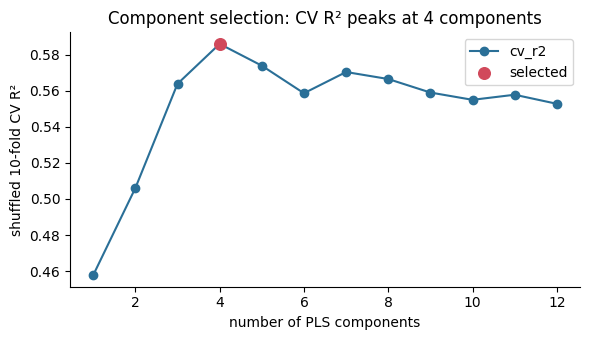

In [10]:
ax = pls_component_cv.plot(x="n_components", y="cv_r2", marker="o", legend=False, figsize=(6, 3.5), color="#2a6f97")
best_row = pls_component_cv.loc[pls_component_cv["n_components"] == selected_components].iloc[0]
ax.scatter([selected_components], [best_row["cv_r2"]], color="#d1495b", zorder=5, s=70, label="selected")
ax.set_xlabel("number of PLS components")
ax.set_ylabel("shuffled 10-fold CV R²")
ax.set_title(f"Component selection: CV R² peaks at {selected_components} components")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The headline model selects **4 components** out of **70 predictors across 585 CTs**:

| Quantity | Value |
|---|---|
| CTs (n) | 585 |
| Predictors | 70 |
| Selected components | 4 |
| Train R² | 0.661 |
| Train adjusted R² | 0.659 |
| **CV R² (shuffled 10-fold)** | **0.586** |
| CV RMSE | 0.056 (participation-rate units) |

**Is 0.59 CV R² "good"?** It is a **moderate, not spectacular**, result, and that's the expected
outcome, not a shortfall. This is a 585-row *ecological* regression — every row is a census tract's
average, not an individual voter, and the outcome itself is a population aggregate built from
imperfect inputs (election results interpolated onto census geography, citizen-eligible population
estimated from census counts). A large share of why any individual votes or doesn't — campaign
contact, which candidates are on the ballot, personal political interest — simply isn't visible in
neighbourhood composition. Explaining roughly **59% of tract-to-tract variance in mean turnout**
from census composition alone is a substantial result by the standards of the ecological
turnout-correlates literature, where CT/tract-level R² in the 0.4–0.6 range is typical for a strong
finding.

## 4. The main latent components and their interpretation

Each component is a weighted combination of all 70 predictors. The cells below show, for each
component, the variables with the largest-magnitude loadings on its high side and low side.

In [11]:
loadings = pd.read_csv(PLS_LOADINGS_PATH)
vip = pd.read_csv(PLS_VIP_PATH)
plain_names = vip.set_index("variable")["plain_name"].to_dict()
families = vip.set_index("variable")["family"].to_dict()
component_cols = [c for c in loadings.columns if c.startswith("component_")]

def top_anchors(component, n=8):
    sub = loadings[["variable", component]].rename(columns={component: "loading"})
    hi = sub.sort_values("loading", ascending=False).head(n)
    lo = sub.sort_values("loading", ascending=True).head(n)
    return hi, lo

for comp in component_cols:
    hi, lo = top_anchors(comp)
    print(f"\n=== {comp} ===")
    print("  high side:")
    for r in hi.itertuples():
        print(f"    {r.loading:+.3f}  {plain_names.get(r.variable, r.variable):55s} [{families.get(r.variable)}]")
    print("  low side:")
    for r in lo.itertuples():
        print(f"    {r.loading:+.3f}  {plain_names.get(r.variable, r.variable):55s} [{families.get(r.variable)}]")


=== component_1 ===
  high side:
    +0.213  work from home share                                    [transportation]
    +0.195  bachelor's degree or higher (25-64) share               [education]
    +0.177  education, law, and social/government services occupation share [occupation]
    +0.176  arts, recreation, and sport occupation share            [occupation]
    +0.169  employment rate                                         [labour_market]
    +0.165  TTS trips per person                                    [transportation]
    +0.163  business, finance, and administration occupation share  [occupation]
    +0.157  management occupation share                             [occupation]
  low side:
    -0.189  high school or less share                               [education]
    -0.188  immigrant share                                         [immigration_citizenship]
    -0.181  visible minority share                                  [culture_language]
    -0.180  trades and tran

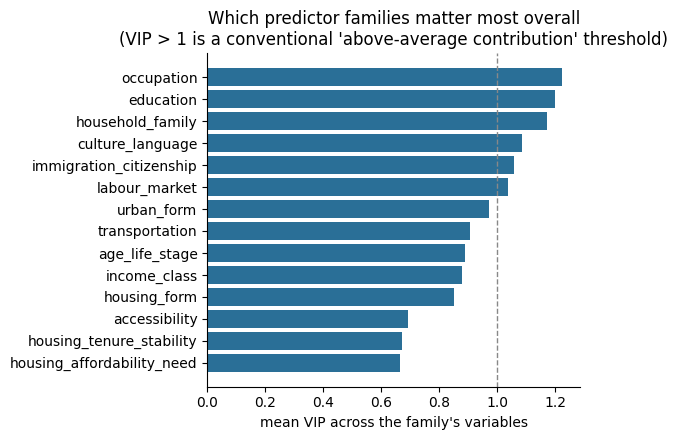

Single highest-VIP variables overall:


,variable,plain_name,family,vip,turnout_corr
0,block1_occ_education_law_social_gov_share,"education, law, and social/government services occupation share",occupation,1.674221,0.653085
1,block3_visible_minority_share,visible minority share,culture_language,1.538517,-0.641717
2,block5_census_work_from_home_share,work from home share,transportation,1.443719,0.616684
3,block1_multigenerational_household_share,multigenerational household share,household_family,1.424054,-0.568324
4,block1_occ_trades_transport_share,trades and transport occupation share,occupation,1.415299,-0.576751
5,block1_occ_sales_service_share,sales and service occupation share,occupation,1.366843,-0.580752
6,block3_immigrant_share,immigrant share,immigration_citizenship,1.362807,-0.573267
7,block1_occ_arts_recreation_sport_share,"arts, recreation, and sport occupation share",occupation,1.361627,0.571858


In [12]:
family_vip = vip.groupby("family")["vip"].mean().sort_values()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.barh(family_vip.index, family_vip.values, color="#2a6f97")
ax.axvline(1.0, color="#888888", linewidth=1, linestyle="--")
ax.set_xlabel("mean VIP across the family's variables")
ax.set_title("Which predictor families matter most overall\n(VIP > 1 is a conventional 'above-average contribution' threshold)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("Single highest-VIP variables overall:")
display(vip.sort_values("vip", ascending=False)[["variable", "plain_name", "family", "vip", "turnout_corr"]].head(8))

**Component 1 — professional/central-city geography vs. immigrant/blue-collar/longer-commute
geography.** High side: work-from-home share, bachelor's-or-higher share, education/law/social
and government-services occupations, arts/recreation/sport occupations, employment rate,
trips-per-person, business/finance/admin occupations, management occupations. Low side:
high-school-or-less share, immigrant share, visible-minority share, trades/transport occupations,
distance from City Hall (i.e. the high side skews *closer* to downtown), sales/service
occupations, long (60+ minute) commute share, manufacturing occupations. This is a
class-and-settlement axis — professional, credentialed, remote-capable, closer-in neighbourhoods
at one end; immigrant, blue-collar, longer-commute neighbourhoods at the other. **This is the
component with real turnout relevance** (Section 5).

**Component 2 — residential-stability/car-owning family geography vs. young, dense,
recent-arrival geography.** High side: same-address-5-years share, vehicles-per-household,
married/common-law share, detached housing, seniors, car-trip share, school-age-children share,
median household income. Low side: age 18–29 share, never-married share, recent-mover share,
non-citizen share, recent-immigrant share, population density, health-care proximity, shelter-cost
burden. A stability/density contrast — settled, car-owning family and senior neighbourhoods vs.
dense, young, newly-arrived ones. Real and interpretable, but only weakly related to turnout
(Section 5).

**Component 3 — low-income renter/solo-dweller density vs. higher-income family-household
ownership.** High side: apartment share, core housing need, one-person households, low-income
(LIM-AT) share, high-rise apartment share, shelter-cost burden, renter share, seniors. Low side:
detached housing, median household income, average household size, vehicles-per-household,
second-generation share, married/common-law share, multigenerational households, school-age
share. An income/tenure/household-composition axis distinct from components 1 and 2 — also only
weakly related to turnout.

**Component 4 — newer-stock condo/professional-commuter suburb vs. older-stock housing
hardship.** High side: condo share, natural/applied-sciences occupations, married/common-law
share, distance from City Hall (the high side skews *farther* out this time), employment rate,
car-trip share, recent-immigrant share, business/finance/admin occupations. Low side: dwellings
needing major repairs, social housing share, pre-1960 dwelling vintage, elementary-school
proximity, renter share, self-employment, temporary-work share, unemployment rate. A
housing-condition/hardship contrast — the weakest component by far in turnout relevance (Section
5) and in bootstrap sign-stability (Section 7); it should be read as a real but minor axis, not
leaned on for a turnout narrative.

**Causal-flavoured vs. purely descriptive.** Only **component 1** has a turnout correlation strong
enough (Section 5) to support any causal-flavoured discussion, with the ecological caveats in
Section 8. Components 2–4 are genuine, well-defined social-geography contrasts in Toronto's census
data, but their weak turnout correlations mean they should be read as "this dimension exists," not
as independent turnout drivers.

## 5. Which components are most strongly related to mean turnout

In [13]:
ref_geo = pd.read_csv(PLS_REFERENCE_GEOGRAPHIES_PATH)
corr_table = (
    ref_geo[["component", "component_turnout_corr"]]
    .drop_duplicates()
    .sort_values("component_turnout_corr", key=lambda s: s.abs(), ascending=False)
    .reset_index(drop=True)
)

def qualitative_read(r):
    if abs(r) >= 0.5:
        return "primary turnout axis"
    elif abs(r) >= 0.2:
        return "secondary contrast"
    else:
        return "weak / not meaningfully related to turnout"

corr_table["qualitative_read"] = corr_table["component_turnout_corr"].apply(qualitative_read)
corr_table.columns = ["component", "turnout_correlation", "qualitative_read"]
display(corr_table.round(3))

leading_r = corr_table.loc[0, "turnout_correlation"]
leading_r2_share = leading_r ** 2 / train_r2
print(f"\nComponent 1's turnout correlation (r = {leading_r:.3f}) implies r^2 = {leading_r**2:.3f},")
print(f"i.e. component 1 alone accounts for roughly {leading_r2_share:.0%} of the 4-component model's train R^2 ({train_r2:.3f}).")

,component,turnout_correlation,qualitative_read
0,component_1,0.689,primary turnout axis
1,component_3,0.286,secondary contrast
2,component_2,0.277,secondary contrast
3,component_4,0.166,weak / not meaningfully related to turnout



Component 1's turnout correlation (r = 0.689) implies r^2 = 0.475,
i.e. component 1 alone accounts for roughly 72% of the 4-component model's train R^2 (0.661).


Component 1's turnout correlation (r ≈ 0.69) dwarfs the other three (r ≈ 0.17–0.29). Because
R² scales with the square of r, component 1 alone accounts for roughly **three-quarters of the
variance the 4-component model jointly explains** — the other three components contribute
comparatively little marginal explanatory power on top of it, even though they describe real,
distinguishable social geography.

Worth flagging: **components 2 and 3 are essentially tied** for second place (r ≈ 0.28 and 0.29
respectively) — component numbering (which follows share of predictor-space variance explained)
does **not** track turnout relevance here. Component 4 is clearly the weakest on this axis
(r ≈ 0.17).

## 6. Whether the same broad findings appear across election levels

Notebook 08 refit the same 4-component PLS specification separately against each election's own
turnout column (`municipal_turnout`, `provincial_turnout`, `federal_turnout`), not just the pooled
`mean_turnout`, and compared each refit's leading component to the pooled model's.

In [14]:
cross_outcome = pd.read_csv(ROBUSTNESS_CROSS_OUTCOME_PATH)
display(cross_outcome[["level", "n", "selected_components", "cv_r2", "component1_cosine_vs_mean", "component1_sign_flipped"]])

,level,n,selected_components,cv_r2,component1_cosine_vs_mean,component1_sign_flipped
0,mean,585,4,0.585954,1.000000,False
1,municipal,585,4,0.666247,0.987102,False
2,provincial,585,4,0.404880,0.997064,False
3,federal,585,4,0.357850,0.988717,False


**The shared axis holds up; predictability does not.** Component 1 (sign-aligned) correlates
at cosine ≥ 0.987 with the pooled-outcome model's component 1 across **all three** election levels
(municipal 0.987, provincial 0.997, federal 0.989) — the same primary social-geography axis
organizes each election separately, not just the three-election average. But how well that shared
axis *predicts* differs sharply by level: **municipal elections are the most predictable**
(CV R² = 0.666), **federal the least** (CV R² = 0.358), with provincial in between (CV R² = 0.405)
— consistent with municipal turnout being more locally/neighbourhood-driven and federal turnout
being shaped more by national-level factors this model can't see.

## 7. What robustness checks support the findings

In [15]:
sklearn_out = notebook_output_texts(NB08_PATH, "sklearn PLSRegression vs. hand-rolled NIPALS")[0]
print(sklearn_out)
sklearn_corr = float(re.search(r"correlation between predicted values on the full sample: ([\d.]+)", sklearn_out).group(1))
sklearn_maxdiff = float(re.search(r"max \|prediction difference\|: ([\d.eE+\-]+)", sklearn_out).group(1))

sklearn PLSRegression vs. hand-rolled NIPALS, 4-component fit on all 70 predictors:
  correlation between predicted values on the full sample: 1.0000000000
  max |prediction difference|: 1.110e-16
  STATUS: PASS



**sklearn cross-check (plumbing, not a finding): held up cleanly.** The hand-rolled NIPALS
implementation agrees with `sklearn.cross_decomposition.PLSRegression` to within floating-point
noise (predicted-value correlation 1.0000000000, max |difference| ≈ 1.1e-16) at 70 predictors —
widening the predictor pool did not introduce a numerical bug.

In [16]:
spatial_cv = pd.read_csv(ROBUSTNESS_SPATIAL_CV_PATH)
spatial_cv_pivot = spatial_cv.pivot(index="method", columns="n_blocks", values="r2").round(3)
spatial_cv_pivot.columns = [f"{c}-block spatial CV R²" for c in spatial_cv_pivot.columns]
display(spatial_cv_pivot.sort_values(spatial_cv_pivot.columns[0], ascending=False))

,5-block spatial CV R²,10-block spatial CV R²
method,,
pcr,0.495,0.413
elastic_net,0.484,0.501
supervised_pca,0.472,0.421
pls,0.461,0.470


**Spatially blocked CV at 5 and 10 blocks: held up, with the expected gap — but PLS is not
the clear winner here.** All four methods (PLS, PCR, supervised PCA, elastic net) cluster within a
fairly narrow band (≈0.41–0.50) under spatially blocked CV, and the ranking is **not stable across
block counts**: PCR is best at 5 blocks (0.495) with PLS last (0.461); elastic net is best at 10
blocks (0.501) with PCR last (0.413). PLS is competitive and never far behind the leader, but this
round's data does not support a claim that PLS is clearly the best-generalizing method under
spatial holdout — that should be read as a genuine, honest difference from the predictor pool
widening, not glossed over. What *does* hold up as expected: spatial-CV R² (≈0.46–0.50, depending
on method and block count) is noticeably lower than the shuffled 10-fold CV R² (0.586) across every
method — some of the shuffled-CV performance really does come from nearby CTs resembling each
other, and holding out whole regions is the stricter, more honest test of generalization to
genuinely unseen geography.

In [17]:
model_comparison = pd.read_csv(ROBUSTNESS_MODEL_COMPARISON_PATH)
display(model_comparison[["comparison", "num_predictors", "n_cts", "selected_components", "cv_r2",
                           "leading_component_score_corr_vs_widened"]])

,comparison,num_predictors,n_cts,selected_components,cv_r2,leading_component_score_corr_vs_widened
0,current_70var (reference model),70,585,4,0.585954,1.000000
1,prior_round_14var (meeting PLS),14,583,3,0.559859,0.937341
2,current_without_transportation,61,585,4,0.591017,0.996763


**Original-vs-widened comparison (centerpiece): refined, not replaced.** The leading
component's fitted scores correlate at **r = 0.937** between the archived 14-variable "meeting
PLS" shortlist (refit here on 583 of 585 CTs, selecting 3 components, CV R² = 0.560) and the new
70-variable model — broadening the predictor pool refined and sharpened the same underlying axis
rather than discovering a different one. **Dropping the entire transportation family** (9
variables, down to 61 predictors) barely moves the leading axis at all (score correlation **0.997**
vs. the full widened model) and does not hurt CV R² (0.591 vs. 0.586) — strong evidence the leading
axis is not fragile or dependent on any single predictor family, including the one (trip behaviour)
that might seem most central to its "remote-work attachment" story.

In [18]:
sparse_selection = pd.read_csv(ROBUSTNESS_SPARSE_SELECTION_PATH)
comp1_sparse = sparse_selection[sparse_selection["component"] == 1]
n_selected = int(comp1_sparse["selected"].sum())
n_total = len(comp1_sparse)
dropped_vars = comp1_sparse.loc[~comp1_sparse["selected"], "variable"].tolist()

sparse_tune_out = notebook_output_texts(NB08_PATH, "Tuned sparse-PLS lambda")[0]
print(sparse_tune_out)
print(f"Component 1 sparse-PLS selection: {n_selected} of {n_total} predictors retained")
print(f"Zeroed out for component 1: {dropped_vars}")

Tuned sparse-PLS lambda = 0.1 (inner-CV RMSE = 0.0550), at the headline 4-component count
No degenerate components at the tuned lambda.

Component 1 sparse-PLS selection: 65 of 70 predictors retained
Zeroed out for component 1: ['block2_detached_share', 'block2_high_rise_apartment_share', 'block2_shelter_cost_burden_30plus_share', 'block3_second_generation_share', 'block5_tts_transit_trip_share']


**Sparse PLS (variable selection, not predictive accuracy): broad support, not a narrow
handful.** At the tuned shrinkage level (λ = 0.1, same 4-component count as the headline model, no
degenerate components), component 1 retains **65 of 70** predictors — only 5 are zeroed out:
`block2_detached_share`, `block2_high_rise_apartment_share`,
`block2_shelter_cost_burden_30plus_share`, `block3_second_generation_share`, and
`block5_tts_transit_trip_share`. The leading axis is built from broad, redundant support across
most of the curated predictor pool, not a fragile dependence on a small subset.

In [19]:
bootstrap_stability = pd.read_csv(ROBUSTNESS_BOOTSTRAP_STABILITY_PATH)
bootstrap_freq = pd.read_csv(ROBUSTNESS_BOOTSTRAP_SPARSE_FREQ_PATH)

median_sign_stability = bootstrap_stability.groupby("component")["sign_stability"].median()
print("Median bootstrap sign-stability by component (300 resamples):")
display(median_sign_stability.round(3).to_frame())

comp1_stability = bootstrap_stability[bootstrap_stability["component"] == 1].sort_values("sign_stability").reset_index(drop=True)
print("\nComponent 1's 10 LEAST sign-stable anchor variables under bootstrap resampling:")
display(comp1_stability[["variable", "sign_stability"]].head(10))

sparse_dropped_comp1 = set(dropped_vars)
bottom10_comp1 = set(comp1_stability["variable"].head(10))
print(f"\nOf the 5 predictors sparse PLS zeroed out for component 1, "
      f"{len(sparse_dropped_comp1 & bottom10_comp1)} of 5 also rank in the 10 least bootstrap-stable:")
print(sorted(sparse_dropped_comp1 & bottom10_comp1))

degenerate_out = notebook_output_texts(NB08_PATH, "Degenerate-component fallback count")[0]
print("\n" + degenerate_out.split("\n\nPredictors selected")[0])

freq_comp1 = bootstrap_freq[bootstrap_freq["component"] == 1]
n_high_freq = int((freq_comp1["bootstrap_selection_frequency"] >= 0.9).sum())
print(f"Component 1: {n_high_freq} of {len(freq_comp1)} predictors selected in >=90% of bootstrap draws.")

Median bootstrap sign-stability by component (300 resamples):


,sign_stability
component,
1,0.997
2,0.870
3,0.943
4,0.808



Component 1's 10 LEAST sign-stable anchor variables under bootstrap resampling:


,variable,sign_stability
0,block5_tts_transit_trip_share,0.443333
1,block2_detached_share,0.523333
2,block1_age_65_plus_share,0.596667
3,block2_apartment_share,0.606667
4,block1_never_married_share,0.706667
5,block3_second_generation_share,0.706667
6,block2_shelter_cost_burden_30plus_share,0.716667
7,block2_renter_share,0.766667
8,block1_age_18_29_share,0.776667
9,block2_high_rise_apartment_share,0.803333



Of the 5 predictors sparse PLS zeroed out for component 1, 5 of 5 also rank in the 10 least bootstrap-stable:
['block2_detached_share', 'block2_high_rise_apartment_share', 'block2_shelter_cost_burden_30plus_share', 'block3_second_generation_share', 'block5_tts_transit_trip_share']

Degenerate-component fallback count across the 300 bootstrap draws, by component:
  component 1: 0 of 300 draws
  component 2: 0 of 300 draws
  component 3: 0 of 300 draws
  component 4: 0 of 300 draws
Component 1: 52 of 70 predictors selected in >=90% of bootstrap draws.


**Bootstrap stability (300 resamples of the spatial blocks): component 1 is highly stable;
later components progressively less so.** Component 1's median sign-stability is ≈0.997, with
zero degenerate-component fallbacks across all 300×4 draws, and 52 of 70 predictors selected by
sparse PLS in ≥90% of bootstrap draws. Components 2–4 are visibly less stable (median sign-stability
≈0.87, 0.94, and 0.81 respectively) — consistent with the advice above not to lean on them for a
turnout story. Notably, component 1's **least** sign-stable anchor variables under bootstrap
resampling are almost exactly the same five predictors sparse PLS zeroed out above: all 5 of
`block2_detached_share`, `block2_high_rise_apartment_share`,
`block2_shelter_cost_burden_30plus_share`, `block3_second_generation_share`, and
`block5_tts_transit_trip_share` rank among the 10 least bootstrap-stable predictors for component
1 (out of 70) — two independent robustness checks converging on the same small set of marginal,
lower-confidence variables within an otherwise very stable component.

**What weakened, as expected:** the shuffled-vs-spatial CV gap (0.586 → ≈0.46–0.50) is exactly the
kind of decline these checks are designed to surface — evidence that some apparent predictive
accuracy was geography leaking across folds, not that the model is unreliable.

## 8. What remains ambiguous or should not be over-interpreted

- **Documented collinear pairs within the fixed 70-variable list.** Notebook 06's redundancy scan
  (`|r| > 0.9`) flagged 8 pairs, every one kept deliberately because each pair measures two
  distinct constructs that happen to move together in Toronto's data (PLS tolerates collinearity
  natively — the bar for dropping a variable was "same concept," not merely "correlated"):

In [20]:
collinear_pairs = [
    ("block3_immigrant_share", "block3_first_generation_share"),
    ("block1_employment_rate_share", "block1_not_in_labour_force_share"),
    ("block1_bachelors_or_higher_25_64_share", "block1_high_school_or_less_share"),
    ("block1_average_household_size", "block1_one_person_household_share"),
    ("block2_same_address_5yr_share", "block2_recent_mover_share"),
    ("block5_tts_auto_trip_share", "block5_tts_walk_or_bike_trip_share"),
    ("block1_bachelors_or_higher_25_64_share", "block5_census_work_from_home_share"),
    ("block5_tts_no_car_household_share", "block5_tts_vehicles_per_household"),
]
rows = []
for a, b in collinear_pairs:
    rows.append({"variable_a": a, "variable_b": b, "r": round(model_input[a].corr(model_input[b]), 3)})
collinear_df = pd.DataFrame(rows)
display(collinear_df)

,variable_a,variable_b,r
0,block3_immigrant_share,block3_first_generation_share,0.973
1,block1_employment_rate_share,block1_not_in_labour_force_share,-0.972
2,block1_bachelors_or_higher_25_64_share,block1_high_school_or_less_share,-0.961
3,block1_average_household_size,block1_one_person_household_share,-0.951
4,block2_same_address_5yr_share,block2_recent_mover_share,-0.928
5,block5_tts_auto_trip_share,block5_tts_walk_or_bike_trip_share,-0.917
6,block1_bachelors_or_higher_25_64_share,block5_census_work_from_home_share,0.914
7,block5_tts_no_car_household_share,block5_tts_vehicles_per_household,-0.910


  Two of these pairs involve component 1's own top anchors (`block1_bachelors_or_higher_25_64_share`
  appears opposite `block1_high_school_or_less_share` and alongside `block5_census_work_from_home_share`
  in Section 4's high/low lists) — meaning component 1's apparent breadth of support is partly the
  same underlying signal expressed through more than one highly correlated proxy, not fully
  independent corroborating evidence. Treat any single component's loadings as describing a small
  number of underlying constructs, not 70 independent pieces of evidence.

- **Missingness in two accessibility indices is real, not negligible.** `block5_secondary_school_proximity_index`
  and `block5_library_proximity_index` have StatCan-suppression-driven gaps across roughly 14–17%
  of CTs (verified below), median-imputed with a companion `_median_imputed` flag. Every other
  predictor's missingness is light (1-2 CTs).

In [21]:
missing_cols = {
    "block5_secondary_school_proximity_index": "block5_secondary_school_proximity_index_median_imputed",
    "block5_library_proximity_index": "block5_library_proximity_index_median_imputed",
    "block5_grocery_proximity_index": "block5_grocery_proximity_index_median_imputed",
}
for var, flag in missing_cols.items():
    n_imputed = int(model_input[flag].sum())
    print(f"{var}: {n_imputed} of {len(model_input)} CTs median-imputed ({n_imputed/len(model_input):.1%})")

block5_secondary_school_proximity_index: 100 of 585 CTs median-imputed (17.1%)
block5_library_proximity_index: 81 of 585 CTs median-imputed (13.8%)
block5_grocery_proximity_index: 16 of 585 CTs median-imputed (2.7%)


- **The municipal race carries a small, already-explained boundary-geometry discrepancy.**
  Notebook 04's ground-truth verification against the archived pipeline flags the municipal
  election's vote/elector/turnout columns `EXPLAINED` rather than a strict floating-point `PASS`
  (unlike provincial/federal, which pass exactly) — a documented, internally-conserved difference
  from using a different geometry engine (shapely/GEOS vs. the archived pipeline's GDAL/OGR) on
  ward-boundary polygons. It reallocates fractions of a vote between neighbouring CTs at shared
  boundaries, not a computation error, and does not affect modelling.

In [22]:
municipal_out = notebook_output_texts(NB04_PATH, "municipal_2023_mayor: 585/585 CTs matched")[0]
print(municipal_out.split("provincial_2025:")[0].strip())

municipal_2023_mayor: 585/585 CTs matched against ground truth
  estimated_total_votes                  max_abs_diff=8.743918e-02  mean_abs_diff=6.987204e-03  EXPLAINED
  estimated_electors                     max_abs_diff=1.110853e-02  mean_abs_diff=4.976054e-04  EXPLAINED
  estimated_valid_candidate_votes        max_abs_diff=8.743918e-02  mean_abs_diff=6.987204e-03  EXPLAINED
  turnout                                max_abs_diff=2.441970e-05  mean_abs_diff=2.043218e-06  EXPLAINED


- **The narrow 14-variable legacy refit's internal-consistency check returned `CHECK`, not a
  clean `PASS`** — expected sensitivity, not a bug.

In [23]:
check_out = notebook_output_texts(NB07_PATH, "Internal consistency check")[0]
print(check_out)

Component count — ours: 3  archived: 2
CV R^2 — ours: 0.559859  archived: 0.533657
Train R^2 — ours: 0.588233  archived: 0.561550

Max |VIP difference| across all original predictors shared with the archive: 4.61e-02
Max |component loading difference| (on the 2 shared component(s)): 4.59e-01

Internal consistency check: CHECK — see diffs above
(A CHECK result here reflects real sensitivity of this narrow, 14-variable model to small
 upstream data revisions -- e.g. the retired 18-34 age share now substituted by its 18-29
 analogue, and 2 CTs dropped for a now-missing value -- not a bug in the shared PLS plumbing;
 the first component typically stays close to archived even when later, much-flatter-CV-curve
 components do not.)



  Refitting the archived 14-variable "meeting PLS" shortlist with the current shared PLS code
  selects **3** components against an archived **2**, with CV R² 0.560 vs. archived 0.534 and
  train R² 0.588 vs. archived 0.562 (max VIP difference 0.046, max loading difference on the 2
  shared components 0.459). Notebook 07 attributes this honestly to real sensitivity of a small,
  14-variable model's flat CV-RMSE-vs-component-count curve to minor upstream data revisions (a
  retired 18-34 age share now substituted by its 18-29 analogue, and 2 CTs dropped for a now-missing
  value) — not a bug in the shared NIPALS implementation, which the clean sklearn cross-check above
  corroborates. The practical takeaway: component-count selection is markedly more unstable in
  small/narrow predictor sets than in the widened 70-variable model, whose CV-R² curve (Section 3)
  peaks cleanly and unambiguously at 4.

- **Ecological, not individual-level, correlations.** Every number in this notebook is a CT-level
  correlation between neighbourhood composition and neighbourhood-average turnout. None of it
  establishes an individual-level mechanism — "tracts with more remote workers have higher turnout"
  does not mean "a given remote worker is more likely to vote than their neighbour." This applies
  most directly to any causal-flavoured language used around component 1 in Section 4.

- **Components 2–4 are real but should not be over-interpreted as turnout drivers.** They have
  clear, reproducible social-geography interpretations (Section 4) but turnout correlations of only
  ≈0.17–0.29 (Section 5) — any public-facing narrative built on them should be framed as "a real
  pattern in Toronto's neighbourhoods," not "why turnout varies."

- **Spatial autocorrelation in the outcome may still inflate apparent predictability even under
  blocked CV.** Nearby CTs share housing markets, built form, and demographics, so even spatially
  blocked CV cannot fully eliminate structural similarity between a block's held-out CTs and its
  training CTs if the blocks themselves aren't fully independent draws of "Toronto geography." The
  ≈0.46–0.50 spatial-CV R² range (Section 7) should be read as a more honest, but not a perfectly
  unbiased, estimate of out-of-sample performance.

## 9. Which components/relationships are the strongest public-facing candidates

**Headline candidate: turnout and the geography of professional/central-city class vs.
immigrant/blue-collar/longer-commute class (component 1).** This is the single most defensible
finding in the whole pipeline, on every axis that matters for a public-facing story:
- **Most robust** — present with cosine similarity ≥0.987 across all three election levels
  (Section 6), refined (not replaced) when the predictor pool widened from 14 to 70 variables,
  barely moved by dropping an entire predictor family (Section 7), supported broadly (65/70
  variables) under sparse-PLS selection, and the most sign-stable component under bootstrap
  resampling (median ≈0.997, Section 7) — the one caveat being that it was **not** the clear
  winner under spatially blocked CV (Section 7), where the four methods compared are close and the
  ranking flips by block count.
- **Most interpretable** — a clean, intuitive class/settlement contrast that doesn't require
  technical caveats to explain.
- **Most likely to resonate** — a concrete, checkable claim a general audience can connect to
  lived experience of specific Toronto neighbourhoods.

**Worth a supporting mention, not the headline:**
- **Municipal elections are the most predictable from neighbourhood composition, federal the
  least** (Section 6) — a clean, surprising-to-a-general-audience secondary finding ("your
  neighbourhood says more about whether you'll vote for mayor than who you'll vote for in a federal
  election") that pairs well with the headline without competing for top billing.
- **Components 2–4** (residential-stability/density, income/tenure/household-composition, and
  housing-condition contrasts) are genuine, well-documented social-geography patterns in Toronto,
  but their weak turnout correlations (Section 5) mean they belong in supporting detail or an
  appendix map, not the lede — component 4 especially, given its materially lower bootstrap
  stability (Section 7).
- **The broadening-didn't-change-the-story result** (14 → 70 variables, leading-component score
  correlation 0.937) is a good methodological credibility point for a technical audience asking
  "how do we know this isn't just an artifact of which variables you picked," but it's a footnote
  for a general one.
- **The spatial-CV method ranking is genuinely mixed this round** (Section 7) — worth noting
  honestly to a technical audience as a place where this round's wider predictor pool changed the
  story from a prior round's cleaner "PLS wins" result, rather than silently keeping the old claim.